In [ ]:
0cc79c26-3350-4e0b-af74-3578c3970157
  - CVAT task: 20260518@1122 - HFE Berries - Olmos
  - Producer :  HFE Berries
  - Friendly name : Blueberry HFE Berries Rocio
f54bc9dd-bb2e-4b46-b332-a14a594245a9 (i took this from ML Dashboard)
  - CVAT task:
  - Producer : Chas de Tavares
  - Friendly name : (field: Quinta do João 2) 
33424749-501c-425e-bea5-3c74fb8539b4
  - CVAT task: 20260510@1522 - Talsa - Viru
  - Producer : Talsa
  - Friendly name : PM02-MOD4 - Talsa
d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
  - CVAT task: 20260518@1201 - HFE Berries - Olmos
  - Producer : HFE Berries
  - Friendly name: Blueberry HFE Berries EB 9-2
7dbfaa1b-19f1-479c-ab0a-b8081516de33
  - CVAT task: 20260520@1101 - San Efisio - Rázuri 
  - Producer : San Efisio
  - Friendly name : San Efisio  V 04 - M14T01 25H field 1

b1d30ef2-0953-45bb-a65f-99770ed0dce3
  - CVAT task: 20260522@1130 - Hortifrut - Almonte
  - producer: Hortifrut 
  - friendly name:Blueberry Greenhouse 1

In [ ]:
# from pathlib import Path
# import shutil
# # FOR EACH Dataset create an images/ labels/ folder with the global class indexes to work on them. Should only run once

# GLOBAL_CLASS_DICT = {"bud":0, "buds":0, "Bud":0, "flower":1, "Flower":1, "green":2, "Green":2, "pink":3, "purple":3, "pink-purple":3, "blue":4}
# # THose are the datasets I will verify my model and finetune on
# uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
#          "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
# for uuid in uuids:
#   RAW_DATASET_ROOT = Path().cwd().parents[0] / "data" / "raw" / "finetuning" / uuid 
#   PROCESSED_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
#   (PROCESSED_DATASET_ROOT / "images").mkdir(parents=True, exist_ok=True)
#   (PROCESSED_DATASET_ROOT / "labels").mkdir(parents=True, exist_ok=True)


#   # CREATE new image-label.txt pairs with global class indexes
#   obj_names_path = RAW_DATASET_ROOT /"annotations/obj.names"
#   local_cls_names = obj_names_path.open(encoding='utf-8').read().splitlines()
#   for cls_name in local_cls_names:
#     if cls_name not in GLOBAL_CLASS_DICT.keys():
#       raise ValueError(f"class {cls_name} not in GLOBAL classes")

#   labels_dir = RAW_DATASET_ROOT / "annotations/obj_train_data"

#   local_class_idx_to_global_map = {i: GLOBAL_CLASS_DICT[cls_name] for i, cls_name in enumerate(local_cls_names)}
#   print(f"Local class names: {local_cls_names} mapped with: {local_class_idx_to_global_map}")
#   for label_file in labels_dir.iterdir():
#     new_lines = []

#     with label_file.open(encoding = 'utf-8') as f:
#       for line in f:
#         parts = line.strip().split()
#         local_cls_idx = int(parts[0])
#         global_cls_idx = local_class_idx_to_global_map[local_cls_idx]
#         parts[0] = str(global_cls_idx)
#         new_lines.append(" ".join(parts))

#     out_label_path = PROCESSED_DATASET_ROOT / "labels" / label_file.name
#     # print(out_label_path)
#     '''
#     out_label_path.write_text("\n".join(new_lines))
#     '''
#     if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
#       img_name = label_file.with_suffix(".jpg").name
#     else:
#       img_name = label_file.with_suffix(".png").name
#     src_img = RAW_DATASET_ROOT / "images" / img_name
#     dst_img = PROCESSED_DATASET_ROOT / "images" / img_name
#     '''
#     if src_img.exists():
#       shutil.copy(src_img ,dst_img)
#     else:
#       raise ValueError(f"{src_img} does not exist")
#     '''

In [2]:
%load_ext autoreload
%autoreload 2
import os
# needed when use_determinist_algoriithms is used in CUDA > 10.2, before importing pytorch
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "0"
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent)) # to be able to import from src

import shutil
import random
from dataclasses import dataclass
# from collections import Counter, defaultdict
from itertools import islice
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import ConfusionMatrixDisplay
from src.utils.metrics import compute_classification_metrics_for_classifier_yolo_comparison
from src.utils.reproducibility import seed_everything
import mlflow
# import mlflow.pytorch

UUIDS = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
         "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]

/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
@dataclass
class BBox:
  cls: int # index
  xc: float # normalized
  yc: float
  w: float
  h: float

  def to_xyxy(self, img_h, img_w) -> tuple[int, int, int, int]:
    x1 = (self.xc - self.w/2) * img_w # x_min
    y1 = (self.yc - self.h/2) * img_h # y_min
    x2 = (self.xc + self.w/2) * img_w # x_max
    y2 = (self.yc + self.h/2) * img_h # y_max
    return x1, y1, x2, y2 # NOTE: removed int(round()) to not lose subpixel precision.. I am not sure it is correct..
    # return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

def load_gt(label_file, img_h, img_w):
  '''
  gt bbox = (cls, [x1,y1,x2,y2])
  '''
  gt_boxes = []
  with label_file.open(encoding='utf-8') as f:
    for line in f:
      cls, xc, yc, w, h = map(float, line.split())
      box = BBox(int(cls),xc,yc,w,h)
      x1, y1, x2, y2 = box.to_xyxy(img_h, img_w)
      gt_boxes.append((int(cls), [x1, y1, x2, y2]))

  return gt_boxes

# ==========================================================================================================================
# LOAD classifier model
seed_everything(123456789)
DEVICE = "cuda:0"
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
# run_id = "7f572b99e4224dbe98221ffff3557390" # swinv2tiny
# run_id = "2ec89cf7ed2e4bac921a69f5902285ab" # swinv2tiny-aug-cosinewr7-defaultsampl
run_id = "7626a94ac30f40bb8b88d3c7e69b9eae" # hpo.convnexttiny.weighted.aug.correct-trial-16 in merged-pinkblue runs
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)
# print(run.data.params['data']) # this is string -> i have to use regular expr to parse mean/std -> ugly!
model = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
model.to(DEVICE)
model.eval()

mean = [0.4291, 0.5388, 0.3654]
std = [0.1871, 0.2131, 0.1977]
inference_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std) # depends on which model i choose , what dataset it was trained
])
# ==========================================================================================================================

datasets:   0%|          | 0/6 [00:08<?, ?it/s]

UUID = f54bc9dd-bb2e-4b46-b332-a14a594245a9
acc 71.79% | balanced_acc: 49.29% | f1_macro: 41.19% | f1_macro_present : 41.19 |f1_weighted: 81.89% | precision_macro: 45.72% | precision_weighted: 95.75% | recall_macro: 49.29% | recall_weighted: 71.79%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,3
flower,0.880,60.684,1.736,117
green,98.463,73.025,83.857,30880
pink-purple,64.338,53.354,58.333,1312
blue,64.909,59.409,62.037,1015
accuracy,71.786,71.786,71.786,0
macro avg,45.718,49.294,41.193,33327
weighted avg,95.746,71.786,81.892,33327


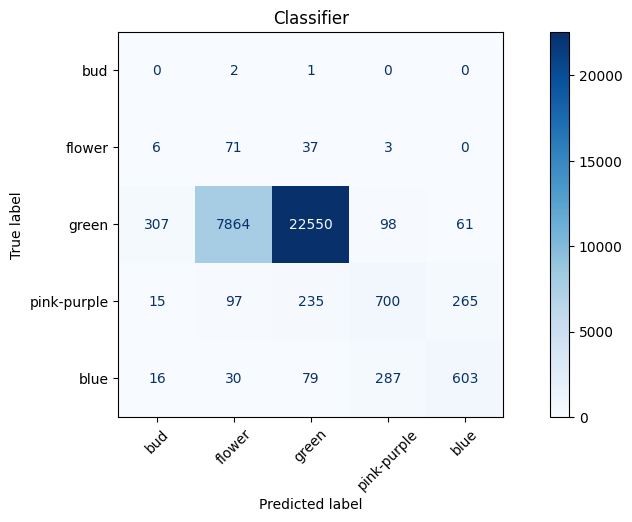

datasets:  17%|█▋        | 1/6 [00:39<00:44,  8.95s/it]

UUID = 33424749-501c-425e-bea5-3c74fb8539b4
acc 85.60% | balanced_acc: 50.14% | f1_macro: 42.34% | f1_macro_present : 42.34 |f1_weighted: 89.51% | precision_macro: 48.87% | precision_weighted: 94.37% | recall_macro: 50.14% | recall_weighted: 85.60%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,1
flower,2.874,68.214,5.515,280
green,96.799,89.213,92.852,70606
pink-purple,56.878,39.081,46.329,3375
blue,87.793,54.169,66.999,2974
accuracy,85.596,85.596,85.596,0
macro avg,48.869,50.136,42.339,77236
weighted avg,94.366,85.596,89.505,77236


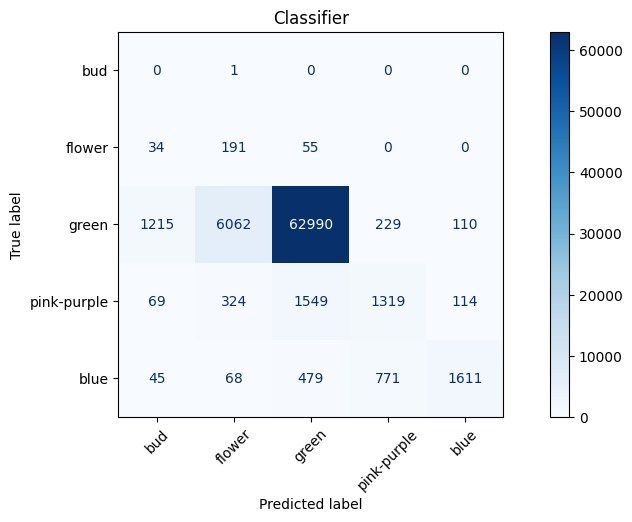

100%|██████████| 300/300 [00:15<00:00, 19.79it/s]0s/it]
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
datasets:  33%|███▎      | 2/6 [00:55<01:27, 21.90s/it]

UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
acc 69.47% | balanced_acc: 49.55% | f1_macro: 43.20% | f1_macro_present : 53.99 |f1_weighted: 71.69% | precision_macro: 50.64% | precision_weighted: 75.21% | recall_macro: 39.64% | recall_weighted: 69.47%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,0
flower,67.509,65.665,66.574,1098
green,82.255,79.906,81.064,2976
pink-purple,34.783,10.435,16.054,230
blue,68.667,42.213,52.284,488
accuracy,69.470,69.470,69.470,0
macro avg,50.643,39.644,43.195,4792
weighted avg,75.214,69.470,71.693,4792


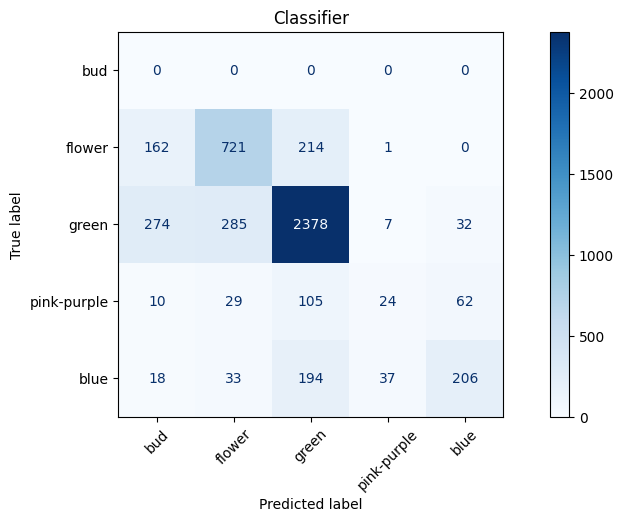

100%|██████████| 300/300 [00:22<00:00, 13.07it/s]6s/it]
/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
datasets:  50%|█████     | 3/6 [01:18<00:56, 18.86s/it]

UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33
acc 82.85% | balanced_acc: 41.04% | f1_macro: 34.13% | f1_macro_present : 42.66 |f1_weighted: 83.13% | precision_macro: 36.92% | precision_weighted: 85.92% | recall_macro: 32.83% | recall_weighted: 82.85%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,0
flower,89.167,57.586,69.979,13307
green,84.657,94.652,89.376,28984
pink-purple,10.753,11.905,11.299,84
blue,0.000,0.000,0.000,1
accuracy,82.846,82.846,82.846,0
macro avg,36.915,32.829,34.131,42376
weighted avg,85.925,82.846,83.128,42376


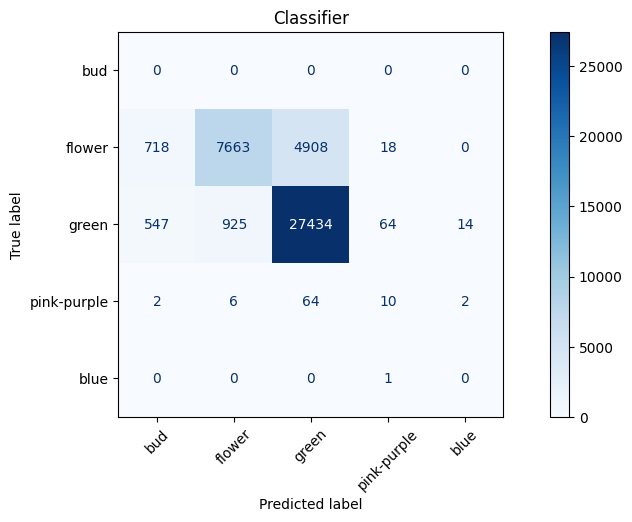

datasets:  67%|██████▋   | 4/6 [01:40<00:41, 20.55s/it]

UUID = 0cc79c26-3350-4e0b-af74-3578c3970157
acc 51.26% | balanced_acc: 52.82% | f1_macro: 42.25% | f1_macro_present : 42.25 |f1_weighted: 52.01% | precision_macro: 51.53% | precision_weighted: 68.21% | recall_macro: 52.82% | recall_weighted: 51.26%


,precision,recall,f1-score,support
bud,37.715,76.581,50.540,5346
flower,11.718,65.274,19.870,1005
green,53.558,66.874,59.480,16105
pink-purple,58.091,17.884,27.348,4697
blue,96.562,37.506,54.028,17749
accuracy,51.261,51.261,51.261,0
macro avg,51.529,52.824,42.253,44902
weighted avg,68.208,51.261,52.013,44902


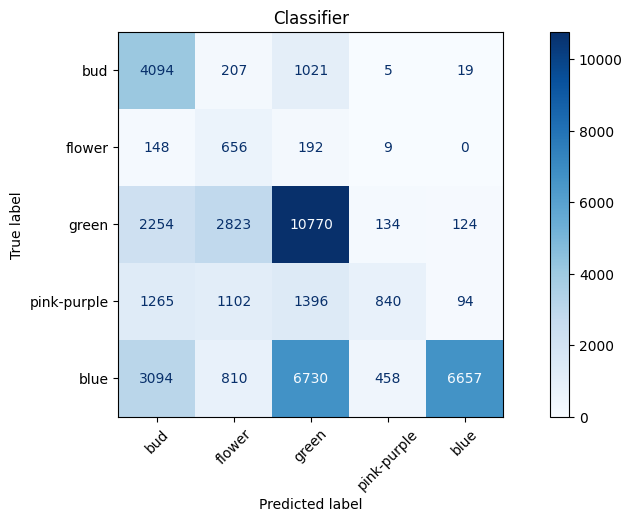

datasets:  83%|████████▎ | 5/6 [01:57<00:21, 21.28s/it]

UUID = b1d30ef2-0953-45bb-a65f-99770ed0dce3
acc 71.77% | balanced_acc: 53.54% | f1_macro: 41.92% | f1_macro_present : 41.92 |f1_weighted: 73.87% | precision_macro: 44.75% | precision_weighted: 77.33% | recall_macro: 53.54% | recall_weighted: 71.77%


,precision,recall,f1-score,support
bud,0.000,0.000,0.000,32
flower,4.985,80.952,9.392,42
green,83.307,85.589,84.433,5003
pink-purple,57.622,41.127,47.996,1296
blue,77.827,60.026,67.777,2339
accuracy,71.775,71.775,71.775,0
macro avg,44.748,53.539,41.920,8712
weighted avg,77.331,71.775,73.869,8712


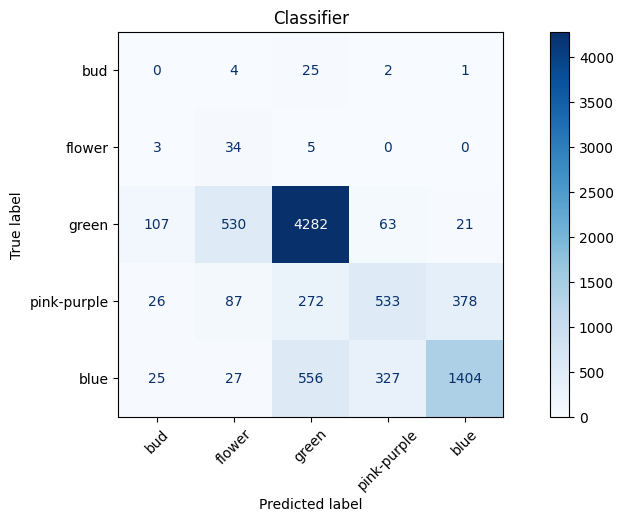

datasets: 100%|██████████| 6/6 [01:57<00:00, 19.63s/it]


In [ ]:
LABEL_IDS = [0, 1, 2, 3, 4]
CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS} # for use in classification report df
uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
         "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
# uuid = "f54bc9dd-bb2e-4b46-b332-a14a594245a9"
for uuid in tqdm(uuids, desc="datasets", position=0):
  TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
  IMAGES_DIR = TEST_DATASET_ROOT / "images"
  LABELS_DIR = TEST_DATASET_ROOT / "labels"

  y_true = []
  y_pred = []
  # for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 2):
  for label_file in tqdm(sorted(LABELS_DIR.iterdir())):
    if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
      img_file = IMAGES_DIR / label_file.with_suffix('.jpg').name
    else:
      img_file = IMAGES_DIR / label_file.with_suffix('.png').name
    img_rgb = Image.open(img_file).convert("RGB")
    img_h, img_w = img_rgb.height, img_rgb.width
    assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

    gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
    if len(gt_boxes) == 0:
      continue
    y_true_per_image = []
    y_pred_per_image = []
    crops = [] # to create a batch with all the boxes from this label file
    for gt in gt_boxes:
      gt_cls, gt_box = gt
      crop = img_rgb.crop(gt_box)
      # crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
      crops.append(inference_transform(crop))
      y_true_per_image.append(gt_cls)
    
    crops_batch = torch.stack(crops).to(DEVICE)
    # print(crops_batch.shape, len(y_true_per_image))
    with torch.inference_mode():
      logits = model(crops_batch).cpu()
      classifier_probs = nn.Softmax(dim=1)(logits)#.cpu() # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).cpu().numpy() # (batch, )
    # classifier_conf = classifier_probs[:, classifier_pred].cpu().numpy()
    # print(classifier_pred.shape)
    # y_pred_per_image.append(classifier_pred)
    y_true.extend(y_true_per_image)
    y_pred.extend(classifier_pred.tolist())

    assert len(y_true_per_image) == len(classifier_pred)

  classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_pred, y_true, LABEL_IDS)
  classifier_classification_report = classifier_metrics['classification_report']

  tqdm.write(f"UUID = {uuid}")
  tqdm.write(f"acc {classifier_metrics['acc']:.2f}% | " f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
        f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | f1_macro_present : {classifier_metrics['f1_macro_present']:.2f} |" f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
        f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | " f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
        f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | " f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
  )
  METRIC_COLUMNS = ["precision", "recall", "f1-score"]
  classifier_df = pd.DataFrame(classifier_classification_report).transpose()
  classifier_df = classifier_df.rename(index=CLASS_MAPPING)
  classifier_df[METRIC_COLUMNS] = classifier_df[METRIC_COLUMNS] * 100
  classifier_df["support"] = classifier_df["support"].astype(int)
  display(classifier_df.style.format(precision=3).set_caption("Classifier"))

  classifier_conf_matrix = classifier_metrics['confusion_matrix']
  fig, ax = plt.subplots(1, 1, figsize=(12,5))
  disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
  # disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
  disp_conf_matrix.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
  ax.set_title("Classifier");
  plt.show()
# swinv2tiny
# UUID = f54bc9dd-bb2e-4b46-b332-a14a594245a9:
# acc 72.56% | balanced_acc: 50.08% | f1_macro: 41.46% | f1_macro_present : 41.460992397735495 |f1_weighted: 82.41% | precision_macro: 46.66% | precision_weighted: 95.77% | recall_macro: 50.08% | recall_weighted: 72.56%
# UUID = 33424749-501c-425e-bea5-3c74fb8539b4
# acc 83.87% | balanced_acc: 49.05% | f1_macro: 42.14% | f1_macro_present : 42.135394899234825 |f1_weighted: 88.65% | precision_macro: 50.04% | precision_weighted: 94.67% | recall_macro: 49.05% | recall_weighted: 83.87%
# UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
# acc 68.82% | balanced_acc: 49.12% | f1_macro: 42.20% | f1_macro_present : 52.74820164295957 |f1_weighted: 70.23% | precision_macro: 48.94% | precision_weighted: 72.86% | recall_macro: 39.29% | recall_weighted: 68.82%
# UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33
# acc 80.40% | balanced_acc: 64.47% | f1_macro: 36.08% | f1_macro_present : 45.09458532426089 |f1_weighted: 80.09% | precision_macro: 38.99% | precision_weighted: 83.41% | recall_macro: 51.57% | recall_weighted: 80.40%
# UUID = 0cc79c26-3350-4e0b-af74-3578c3970157
# acc 48.20% | balanced_acc: 50.47% | f1_macro: 39.73% | f1_macro_present : 39.72908665966492 |f1_weighted: 49.52% | precision_macro: 51.89% | precision_weighted: 67.75% | recall_macro: 50.47% | recall_weighted: 48.20%
# UUID = b1d30ef2-0953-45bb-a65f-99770ed0dce3
# acc 70.59% | balanced_acc: 50.00% | f1_macro: 40.21% | f1_macro_present : 40.207672294586146 |f1_weighted: 72.42% | precision_macro: 44.33% | precision_weighted: 76.40% | recall_macro: 50.00% | recall_weighted: 70.59%

# convnexttiny:
# UUID = f54bc9dd-bb2e-4b46-b332-a14a594245a9
# acc 71.79% | balanced_acc: 49.29% | f1_macro: 41.19% | f1_macro_present : 41.19 |f1_weighted: 81.89% | precision_macro: 45.72% | precision_weighted: 95.75% | recall_macro: 49.29% | recall_weighted: 71.79%
# UUID = 33424749-501c-425e-bea5-3c74fb8539b4
# acc 85.60% | balanced_acc: 50.14% | f1_macro: 42.34% | f1_macro_present : 42.34 |f1_weighted: 89.51% | precision_macro: 48.87% | precision_weighted: 94.37% | recall_macro: 50.14% | recall_weighted: 85.60%
# UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
# acc 69.47% | balanced_acc: 49.55% | f1_macro: 43.20% | f1_macro_present : 53.99 |f1_weighted: 71.69% | precision_macro: 50.64% | precision_weighted: 75.21% | recall_macro: 39.64% | recall_weighted: 69.47%
# UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33
# acc 82.85% | balanced_acc: 41.04% | f1_macro: 34.13% | f1_macro_present : 42.66 |f1_weighted: 83.13% | precision_macro: 36.92% | precision_weighted: 85.92% | recall_macro: 32.83% | recall_weighted: 82.85%
# UUID = 0cc79c26-3350-4e0b-af74-3578c3970157
# acc 51.26% | balanced_acc: 52.82% | f1_macro: 42.25% | f1_macro_present : 42.25 |f1_weighted: 52.01% | precision_macro: 51.53% | precision_weighted: 68.21% | recall_macro: 52.82% | recall_weighted: 51.26%
# UUID = b1d30ef2-0953-45bb-a65f-99770ed0dce3
# acc 71.77% | balanced_acc: 53.54% | f1_macro: 41.92% | f1_macro_present : 41.92 |f1_weighted: 73.87% | precision_macro: 44.75% | precision_weighted: 77.33% | recall_macro: 53.54% | recall_weighted: 71.77%

In [ ]:
UUID = f54bc9dd-bb2e-4b46-b332-a14a594245a9
acc 72.56% | balanced_acc: 50.08% | f1_macro: 41.46% | f1_weighted: 82.41% | precision_macro: 46.66% | precision_weighted: 95.77% | recall_macro: 50.08% | recall_weighted: 72.56
UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
acc 68.82% | balanced_acc: 49.12% | f1_macro: 42.20% | f1_weighted: 70.23% | precision_macro: 48.94% | precision_weighted: 72.86% | recall_macro: 39.29% | recall_weighted: 68.82%

UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33
acc 80.40% | balanced_acc: 64.47% | f1_macro: 36.08% | f1_weighted: 80.09% | precision_macro: 38.99% | precision_weighted: 83.41% | recall_macro: 51.57% | recall_weighted: 80.40%

In [ ]:
# CREATE finetuning-split-n_images datasets for each UUID
'''
rng = random.Random(42)

N_IMAGES_TO_USE_IN_FINETUNE = [50, 100, 150]
# uuid = UUIDS[0]
for uuid in UUIDS:
  GLOBAL_LABELS_SRC_DATASET = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
  GLOBAL_LABELS_IMAGES_DIR = GLOBAL_LABELS_SRC_DATASET / "images"
  GLOBAL_LABELS_LABELS_DIR = GLOBAL_LABELS_SRC_DATASET / "labels"

  for n_images in N_IMAGES_TO_USE_IN_FINETUNE:
    # dataset root for each finetune sample size
    BEFORE_SPLIT_ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-before-split-{n_images}"
    BEFORE_SPLIT_DATASET = BEFORE_SPLIT_ROOT / uuid
    if BEFORE_SPLIT_ROOT.exists():
      shutil.rmtree(BEFORE_SPLIT_ROOT)
    for cls_id in range(5):
      (BEFORE_SPLIT_DATASET / str(cls_id)).mkdir(parents=True, exist_ok=True)

    label_files_names = ([f for f in GLOBAL_LABELS_LABELS_DIR.iterdir() if f.stat().st_size>0]) # ignore empty label files
    label_files_sample = rng.sample(label_files_names, min(len(label_files_names), n_images)) # if labels < 150 for one uuid use them all
    # print(label_files_sample[:3])
    # print(f"sample {n_images}")
    # print(f"Total label files: {len(label_files_names)}")
    # print(f"sampled = {len(label_files_sample)}")
    # create dataset from the boxes for the selected amount of images
    for label_file in label_files_sample:
      suffix = ".jpg" if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9" else ".png"
      img_path = GLOBAL_LABELS_IMAGES_DIR / label_file.with_suffix(suffix).name
      img_rgb = Image.open(img_path).convert("RGB")
      img_h, img_w = img_rgb.height, img_rgb.width
      assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

      gt_boxes = load_gt(label_file, img_h, img_w)
      assert gt_boxes, f"parsed empty label file {label_file}. Shouldn't happen"

      # copy bboxes to intermidiate before-split dataset for each cls
      for i, (gt_cls, gt_box) in enumerate(gt_boxes):
        crop = img_rgb.crop(gt_box)
        dst_box_path = BEFORE_SPLIT_DATASET / f"{str(gt_cls) + '/' + img_path.stem}_{i}.png" # write all crops as png ,even from .jpg images
        # print(dst_box_path)
        crop.save(dst_box_path)


    # SPLITTED_ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted-{n_images}"
    SPLITTED_ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted8020-{n_images}" # for 80-20 split
    SPLITTED_DATASET = SPLITTED_ROOT / uuid
    if SPLITTED_DATASET.exists():
      shutil.rmtree(SPLITTED_DATASET)
    (train_folder := SPLITTED_DATASET / "train").mkdir(parents=True, exist_ok=True)
    (dev_folder := SPLITTED_DATASET / "dev").mkdir(parents=True, exist_ok=True)
    train_ratio = 0.8 # 90% train, 10% dev

    for cls_dir in BEFORE_SPLIT_DATASET.iterdir():
      cls_name = cls_dir.name
      (train_class_folder := train_folder / cls_name).mkdir(parents=True, exist_ok=True)
      (dev_class_folder := dev_folder / cls_name).mkdir(parents=True, exist_ok=True)

      images = list(cls_dir.glob(f"*.png"))
      rng.shuffle(images)

      split_idx = int(len(images) * train_ratio)
      train_images = images[:split_idx]
      dev_images = images[split_idx:]

      # print("train, test len =", len(train_images), len(dev_images))
      # copy files
      for img_path in train_images:
        shutil.copy(img_path, train_class_folder / img_path.name)
      for img_path in dev_images:
        shutil.copy(img_path, dev_class_folder / img_path.name)

    # Delete intermediate before-split dataset
    if BEFORE_SPLIT_ROOT.exists():
      shutil.rmtree(BEFORE_SPLIT_ROOT)
'''

In [25]:
from typing import Union
import torchvision
import timm

'''
def freeze_swinv2_backbone(model):
  for param in model.parameters():
    param.requires_grad = False
  for param in model.head.parameters():
    param.requires_grad = True
  # for name, param in model.named_parameters():
  #   if not name.startswith("head"):
  #     param.requires_grad = False
  #   else:
  #     param.requires_grad = True
'''

def freeze_backbone(model: Union[torchvision.models.convnext.ConvNeXt, timm.models.swin_transformer_v2.SwinTransformerV2]):
  if isinstance(model, timm.models.swin_transformer_v2.SwinTransformerV2):
    for param in model.parameters():
      param.requires_grad = False
    for param in model.head.parameters():
      param.requires_grad = True
  elif isinstance(model, torchvision.models.convnext.ConvNeXt):
    for param in model.parameters():
      param.requires_grad = False
    for param in model.classifier.parameters():
      param.requires_grad = True

In [26]:
# finetune
from src.trainers.default import Trainer
from torch.optim import AdamW
import warnings
from sklearn.exceptions import UndefinedMetricWarning
# warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore", module="sklearn.metrics._classification")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false" # for mlflow progress bar
from collections import defaultdict

LABEL_IDS = [0,1,2,3,4]
CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS}

seed_everything(123456789)
g = torch.Generator().manual_seed(123456789)
device = torch.device("cuda:1")
EPOCHS = 100
BATCH_SIZE = 128
# ============================================================
# run_id = "7f572b99e4224dbe98221ffff3557390" # swinv2tiny
run_id = "7626a94ac30f40bb8b88d3c7e69b9eae" # hpo.convnexttiny.weighted.aug.correct-trial-16 in merged-pinkblue runs
client = mlflow.tracking.MlflowClient()
run = client.get_run(run_id)
# ============================================================

LR = 1e-4
loss_fn = nn.CrossEntropyLoss()

mean = [0.4291, 0.5388, 0.3654]
std = [0.1871, 0.2131, 0.1977]
train_transforms = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  # v2.RandomHorizontalFlip(p=0.5),
  # v2.RandomVerticalFlip(p=0.5),
  # v2.RandomRotation(degrees=10),
  # v2.ColorJitter(brightness=0.1),
  v2.Normalize(mean=mean, std=std)
])

dev_transforms = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64), interpolation=v2.InterpolationMode.BICUBIC),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=mean, std=std)
])

def get_loaders(uuid_path: Path):
  train_ds = ImageFolder(uuid_path / "train", transform=train_transforms, allow_empty=True)
  dev_ds   = ImageFolder(uuid_path / "dev", transform=dev_transforms, allow_empty=True)
  train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=6, generator=g, pin_memory=True, persistent_workers=True, prefetch_factor=4)
  dev_loader   = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=6, generator=g, pin_memory=True, persistent_workers=True, prefetch_factor=4)

  return train_loader, dev_loader

# {"uuid": {'50': {'f1': []}, '100':{'f1': []}, '150':{'f1': []}}}
METRICS_DICT = defaultdict(
  lambda: defaultdict(
    lambda: defaultdict(list)
  )
)

f1_per_class_d = defaultdict(list)

N_IMAGES_TO_USE_IN_FINETUNE = [50, 100, 150]
# n_images = N_IMAGES_TO_USE_IN_FINETUNE[0]
for n_images in N_IMAGES_TO_USE_IN_FINETUNE:
  # ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted-{n_images}"
  ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted8020-{n_images}" # for finetuning on 80-20 split
  # match = re.search(r"(\d+)$", ROOT.name)
  # sample_images_str = match.group(1) # number of sampled images

  # for uuid_dir in islice(ROOT.iterdir(), 2):
  for uuid_dir in ROOT.iterdir():
    print(f"UUID = {uuid_dir.name} Sample {n_images}")
    train_loader, dev_loader = get_loaders(uuid_dir)
    # print(len(train_loader), len(dev_loader))
    # ================================================================
    model = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
    model.to(device)
    # freeze_swinv2_backbone(model)
    freeze_backbone(model)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable model params: {trainable} out of total: {total}")
    # ================================================================
    # print(f"Ensure reproducibility: {model.head.fc.weight.data[:1, :2]}")
    # print(f"Ensure reproducibility: {model.classifier[2].weight.data[:1, :2]}")
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    trainer = Trainer(model, train_loader, dev_loader, None, loss_fn, optimizer, None, device)

    lossi = []
    dev_lossi = []
    dev_f1_macro = []
    dev_f1_weighted = []
    pbar = tqdm(range(EPOCHS), desc="Main Loop", unit="epoch")
    for epoch in pbar:
      loss, metrics = trainer.train_one_epoch()
      dev_loss, dev_metrics = trainer.validate_one_epoch()
      pbar.set_postfix({ "train_loss": f"{loss:.7f}", "dev_loss": f"{dev_loss:.7f} {dev_metrics['f1_macro']}"})
      # lossi.append(loss)
      # dev_lossi.append(dev_loss)
      # dev_f1_macro.append(dev_metrics['f1_macro'])
      METRICS_DICT[uuid_dir.name][str(n_images)]['f1_macro'].append(dev_metrics['f1_macro'])
      METRICS_DICT[uuid_dir.name][str(n_images)]['f1_macro_present'].append(dev_metrics['f1_macro_present'])
      METRICS_DICT[uuid_dir.name][str(n_images)]['coverage'].append(dev_metrics['coverage'])
      # print(dev_metrics['f1_macro_per_class'])
      # print(dev_metrics['classification_report'])
      for k, v in (report:=dev_metrics['classification_report']).items():
        # print(k, v)
        # keep metrics from classification report only per classs
        if k in [str(l) for l in LABEL_IDS]:
          METRICS_DICT[uuid_dir.name][str(n_images)][CLASS_MAPPING[k]].append(v['f1-score'])
          # print(f" {k} : {v['f1-score']}")

      # print(dev_metrics['classification_report'])

UUID = 33424749-501c-425e-bea5-3c74fb8539b4 Sample 50
Trainable model params: 5381 out of total: 27823973


Main Loop: 100%|██████████| 100/100 [02:12<00:00,  1.32s/epoch, train_loss=0.0915011, dev_loss=0.1336708 47.8937158378853] 


UUID = 7dbfaa1b-19f1-479c-ab0a-b8081516de33 Sample 50
Trainable model params: 5381 out of total: 27823973


Main Loop: 100%|██████████| 100/100 [01:46<00:00,  1.06s/epoch, train_loss=0.1697635, dev_loss=0.2227963 36.281970126048094]


UUID = d83c7c85-54d9-4b6e-ab2e-3fdec827c22c Sample 50
Trainable model params: 5381 out of total: 27823973


...

Main Loop: 100%|██████████| 100/100 [04:20<00:00,  2.60s/epoch, train_loss=0.0784784, dev_loss=0.1307338 46.46007845515654]


UUID = b1d30ef2-0953-45bb-a65f-99770ed0dce3 Sample 150
Trainable model params: 5381 out of total: 27823973


Main Loop: 100%|██████████| 100/100 [01:15<00:00,  1.32epoch/s, train_loss=0.2786800, dev_loss=0.3667022 48.29696212564564]


UUID = 0cc79c26-3350-4e0b-af74-3578c3970157 Sample 150
Trainable model params: 5381 out of total: 27823973


Main Loop: 100%|██████████| 100/100 [03:26<00:00,  2.07s/epoch, train_loss=0.3913465, dev_loss=0.4386523 76.13259238049609]


In [1]:
METRICS_DICT
# METRICS_DICT['33424749-501c-425e-bea5-3c74fb8539b4']

NameError: name 'METRICS_DICT' is not defined

In [9]:
# save metrics - Carefull not to override something!
import pickle
import json
# with open("convnexttiny-finetune.pkl", "wb") as f:
  # pickle.dump(dict(METRICS_DICT), f)

# metrics_save_path = "convnexttiny-finetune.json"
# metrics_save_path = "swinv2tiny-finetune8020.json"
# with open(metrics_save_path, "w") as f:
  # json.dump(dict(METRICS_DICT), f, indent=2)

def load_finetune_metrics(json_path:Path):
  # with open(metrics_save_path, "r") as f:
  with json_path.open("r") as f:
    return json.load(f)

def save_finetune_metrics(json_path:Path):
  with open(json_path, "w") as f:
    json.dump(dict(METRICS_DICT), f, indent=2)

# run_name = "swinv2tiny-finetune8020"
run_name = "convnexttiny-finetune8020-fixed-metrics"
metrics_save_path = Path(f"finetuning/metrics/{run_name}.json")
# save_finetune_metrics(metrics_save_path)

In [ ]:
# NOTE: Load metrics file
run_name = "convnexttiny-finetune8020-fixed-metrics"
metrics_load_path = Path(f"finetuning/metrics/{run_name}.json")
assert metrics_load_path.exists(), "run_name doesn't exist"
# METRICS_DICT = load_finetune_metrics(metrics_load_path)
# print(METRICS_DICT)

{'33424749-501c-425e-bea5-3c74fb8539b4': {'50': {'f1_macro': [43.57671723355418, 44.01642801642801, 45.00248375976531, 45.21717624297683, 45.19933620207013, 45.10238245151925, 45.669701832752395, 45.81087584414359, 45.89416193855934, 46.446164181613035, 46.275919997145216, 46.28521840545766, 46.29989056342296, 46.27732262969769, 46.56715804216396, 46.44947510262362, 46.866725922344116, 46.81053214931559, 47.424951754379904, 47.68227061039834, 47.63438219041689, 47.68676753860346, 47.88558367555024, 48.186368566908094, 47.81849915314403, 48.415254254180425, 48.405789050665426, 47.66801306157822, 48.26081409974027, 48.15039472852683, 48.22456652219402, 48.15039472852683, 48.21656921558205, 48.06907545959888, 48.2529183239803, 48.028722859096405, 47.9444698591618, 48.07873652373449, 48.61365222822293, 48.6244934423555, 48.83852640746403, 48.45085077880419, 48.8032424575724, 48.57866728546348, 48.5039678892055, 48.631624615305036, 48.68495814452743, 48.55746539579361, 48.55746539579361, 48

[43.525699734415085, 44.06656704229546, 44.89178329909688]
[45.364134895391516, 46.421280878371185, 48.34163458366388]
[45.73816453352789, 46.159549301877725, 46.41821719098959]


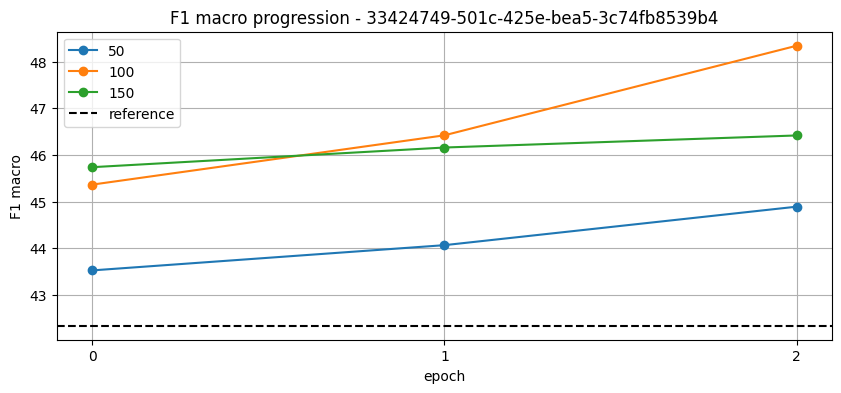

[37.05373756929433, 37.49092463565313, 37.78780623846914]
[34.322841159061525, 34.91023013347176, 35.41662472308677]
[40.181171592895694, 41.33165202741819, 41.46351249923785]


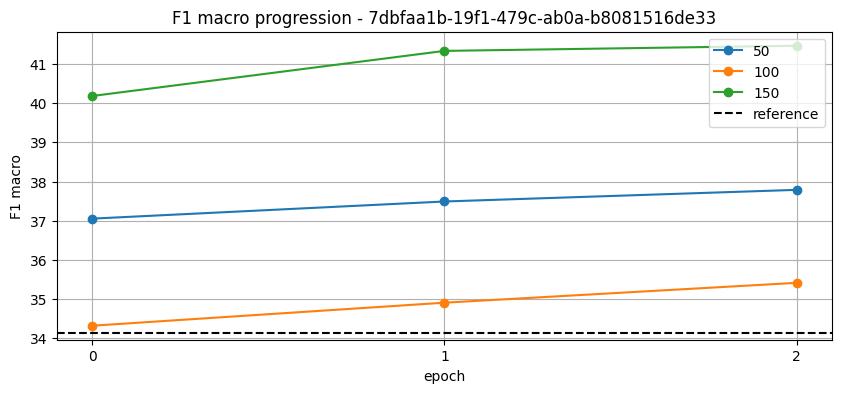

In [75]:
from matplotlib.ticker import MaxNLocator

# output_dir = Path("plots")
output_dir = Path("finetuning/plots")
output_dir.mkdir(exist_ok=True)
# run_name = "swinv2tiny8020"
run_name = "convnexttiny8020-aug"

# for swinv2tiny
swinv2tiny_reference_f1 = {
  "33424749-501c-425e-bea5-3c74fb8539b4": 42.14,
  "0cc79c26-3350-4e0b-af74-3578c3970157": 39.73,
  "b1d30ef2-0953-45bb-a65f-99770ed0dce3": 40.21,
  "f54bc9dd-bb2e-4b46-b332-a14a594245a9": 41.46,
  "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c": 42.20,
  "7dbfaa1b-19f1-479c-ab0a-b8081516de33": 36.08
}
convnexttiny_reference_f1 = {
  "33424749-501c-425e-bea5-3c74fb8539b4": 42.34,
  "0cc79c26-3350-4e0b-af74-3578c3970157": 42.25,
  "b1d30ef2-0953-45bb-a65f-99770ed0dce3": 41.92,
  "f54bc9dd-bb2e-4b46-b332-a14a594245a9": 41.19,
  "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c": 43.20,
  "7dbfaa1b-19f1-479c-ab0a-b8081516de33": 34.13 
}

# reference = defaultdict(dict)

for uuid, splits in METRICS_DICT.items():
  plt.figure(figsize=(10, 4))
  for split in ["50", "100", "150"]:
    values = splits[split]["f1_macro"]
    # values = splits[split]["f1_macro_present"]
    print(values)
    steps = list(range(len(values)))  # x-axis = progression steps

    plt.plot(steps, values, marker='o', label=f"{split}")

  # reference line
  # if uuid in swinv2tiny_reference_f1:
    # ref = swinv2tiny_reference_f1[uuid]
  if uuid in convnexttiny_reference_f1:
    ref = convnexttiny_reference_f1[uuid]
    plt.axhline(ref, linestyle='--', color='black', label='reference')

  plt.title(f"F1 macro progression - {uuid}")
  plt.xlabel("epoch")
  plt.ylabel("F1 macro")
  plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # to remove 0.25, 0.5 .. from x axis
  plt.legend()
  plt.grid(True)

  # save figure
  # filename = output_dir / f"{run_name}-{uuid}.png"
  # plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()
  plt.close()

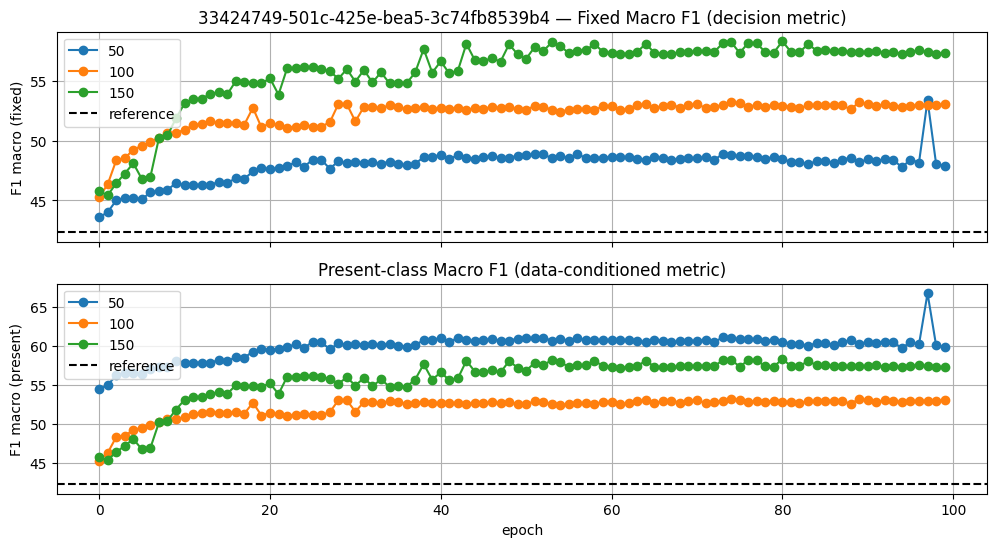

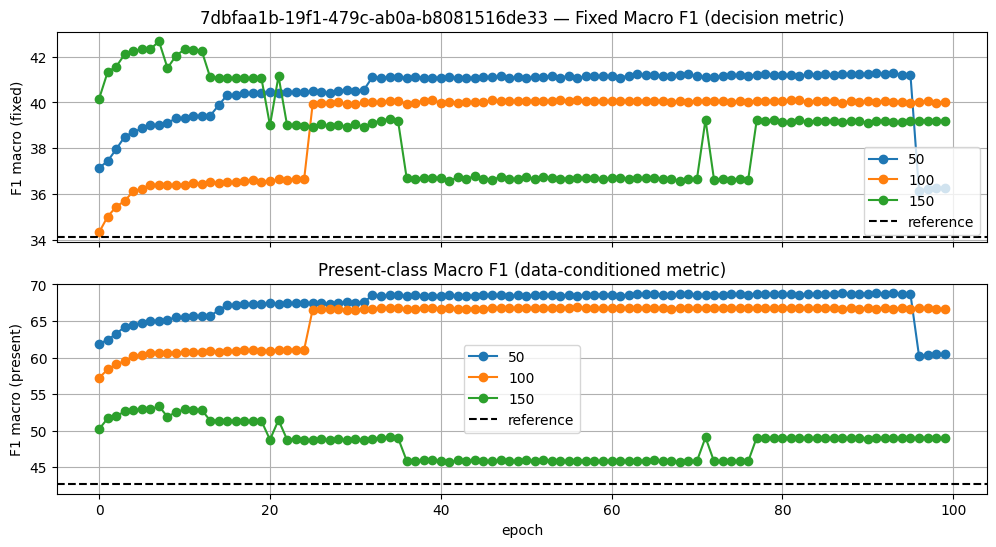

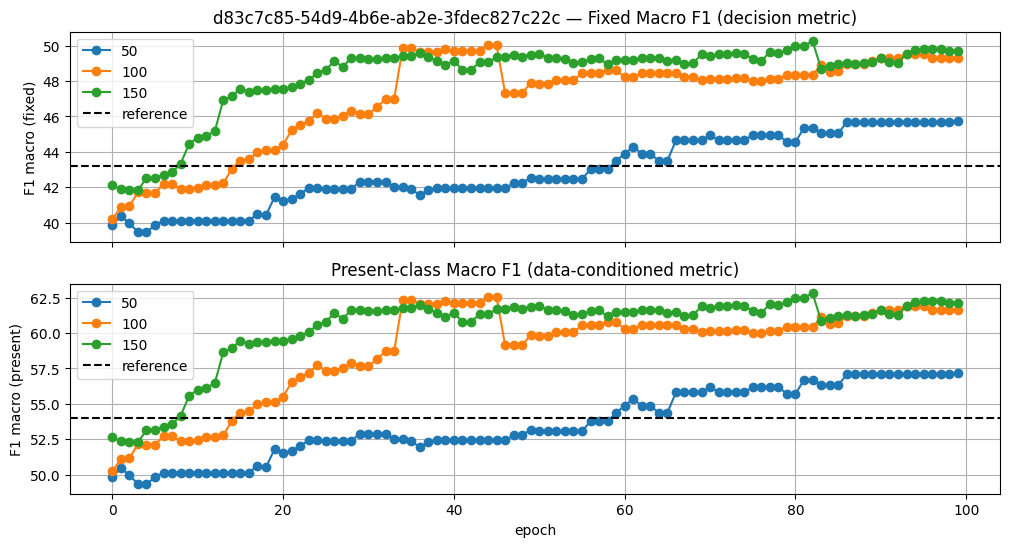

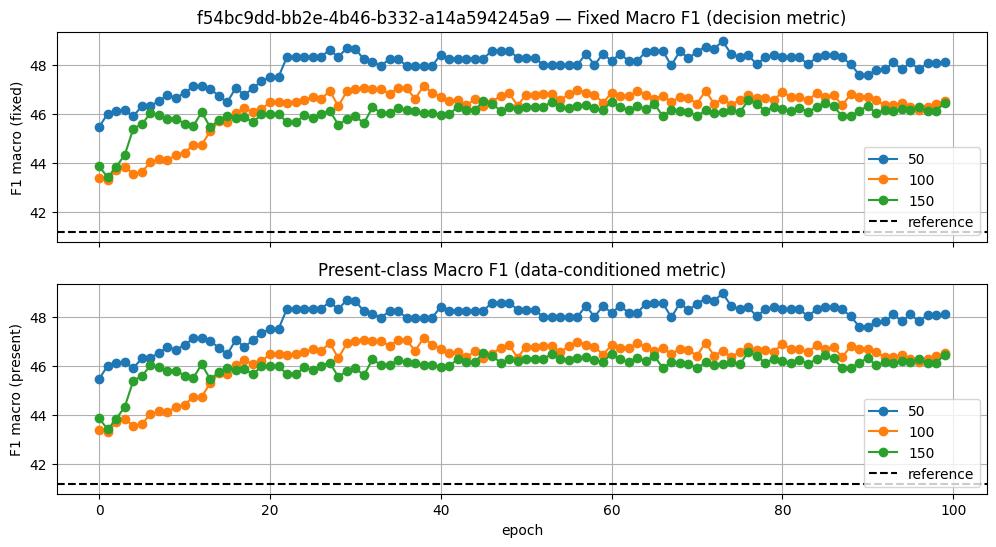

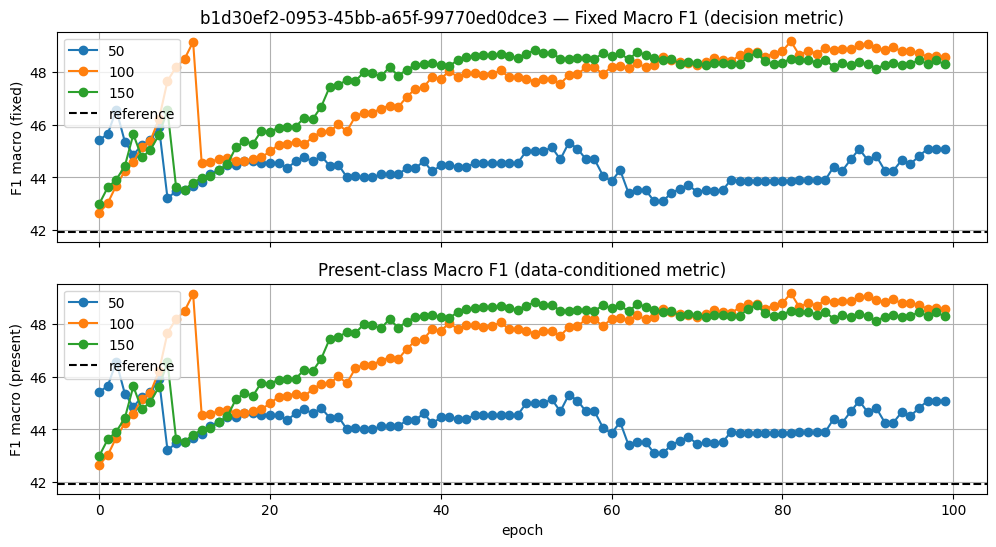

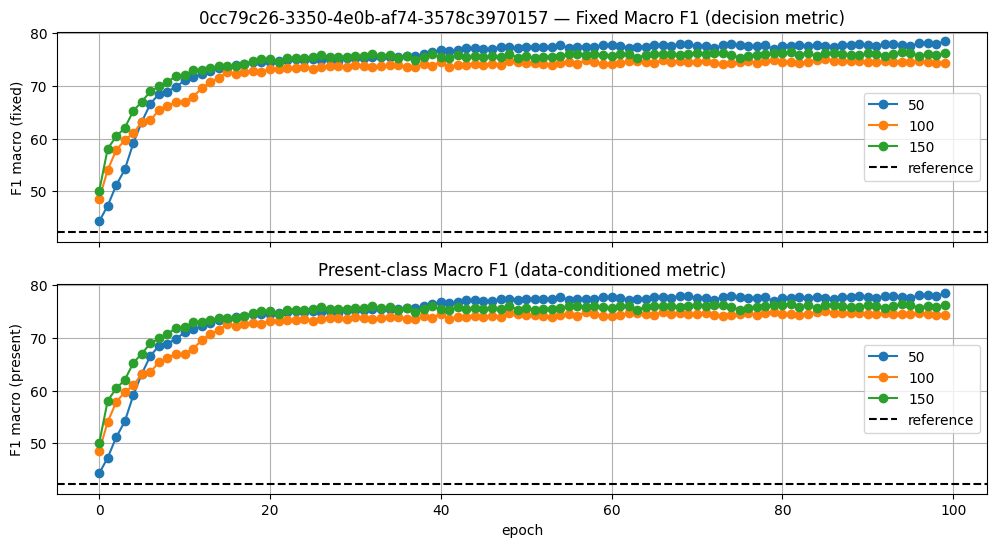

In [ ]:
from matplotlib.ticker import MaxNLocator

output_dir = Path("finetuning/plots")
output_dir.mkdir(exist_ok=True)
# run_name = "swinv2tiny8020"
run_name = "convnexttiny8020-fixedmetrics"

# TODO: These need to be updated to fixed or present f1 scores !!
convnexttiny_reference_f1_fixed = {
  "33424749-501c-425e-bea5-3c74fb8539b4": 42.34,
  "0cc79c26-3350-4e0b-af74-3578c3970157": 42.25,
  "b1d30ef2-0953-45bb-a65f-99770ed0dce3": 41.92,
  "f54bc9dd-bb2e-4b46-b332-a14a594245a9": 41.19,
  "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c": 43.20,
  "7dbfaa1b-19f1-479c-ab0a-b8081516de33": 34.13 
}
convnexttiny_reference_f1_present = {
  "33424749-501c-425e-bea5-3c74fb8539b4": 42.34,
  "0cc79c26-3350-4e0b-af74-3578c3970157": 42.25,
  "b1d30ef2-0953-45bb-a65f-99770ed0dce3": 41.92,
  "f54bc9dd-bb2e-4b46-b332-a14a594245a9": 41.19,
  "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c": 53.99,
  "7dbfaa1b-19f1-479c-ab0a-b8081516de33": 42.66 
}

# reference = defaultdict(dict)

for uuid, splits in METRICS_DICT.items():
  fig, axes = plt.subplots(2,1,figsize=(12, 6), sharex=True)
  for split in ["50", "100", "150"]:
    steps = range(len(splits[split]["f1_macro"]))
    # --- FIXED MACRO (top) ---
    axes[0].plot(steps, splits[split]["f1_macro"], marker='o', label=f"{split}")
    # --- PRESENT MACRO (bottom) ---
    axes[1].plot(steps, splits[split]["f1_macro_present"], marker='o', label=f"{split}")

  # reference line
  if uuid in (d:=convnexttiny_reference_f1_fixed):
    ref = d[uuid]
    axes[0].axhline(ref, linestyle='--', color='black', label='reference')
  if uuid in (d:=convnexttiny_reference_f1_present):
    ref = d[uuid]
    axes[1].axhline(ref, linestyle='--', color='black', label='reference')

  axes[0].set_title(f"{uuid} — Fixed Macro F1 (decision metric)")
  axes[1].set_title("Present-class Macro F1 (data-conditioned metric)")
  axes[0].set_ylabel("F1 macro (fixed)")
  axes[1].set_ylabel("F1 macro (present)")
  axes[1].set_xlabel("epoch")
  axes[0].grid(True)
  axes[1].grid(True)
  axes[0].legend()
  axes[1].legend()

  # save figure
  # filename = output_dir / f"{run_name}-{uuid}.png"
  # plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()
  plt.close()

In [41]:
# METRICS_DICT['33424749-501c-425e-bea5-3c74fb8539b4']['50']['green']

finetuning/plots/per-class/pink-purple True


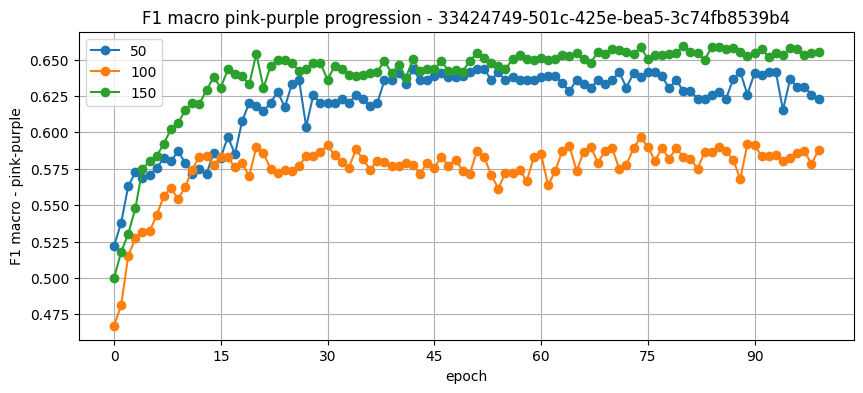

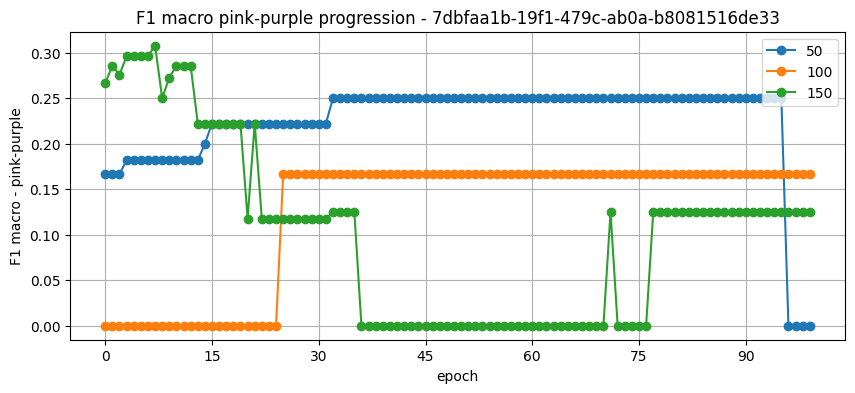

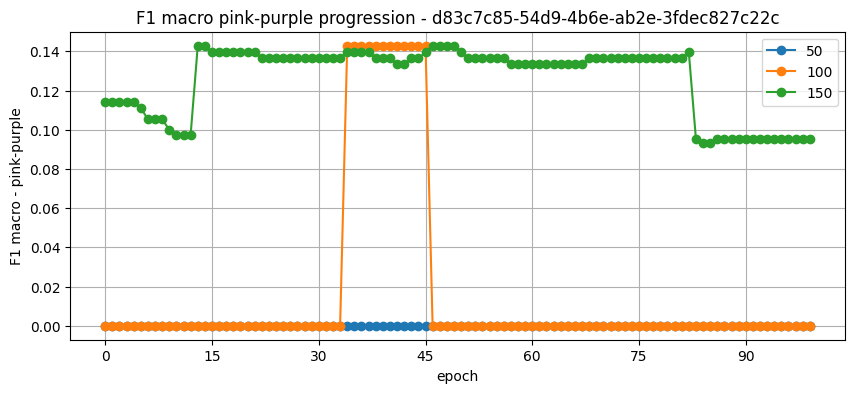

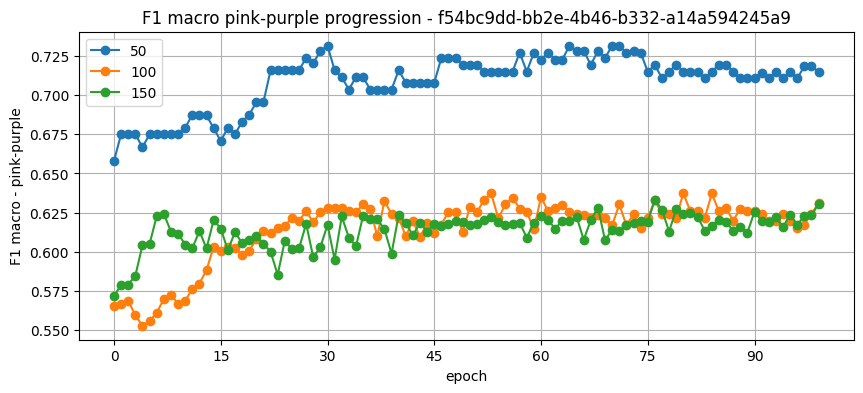

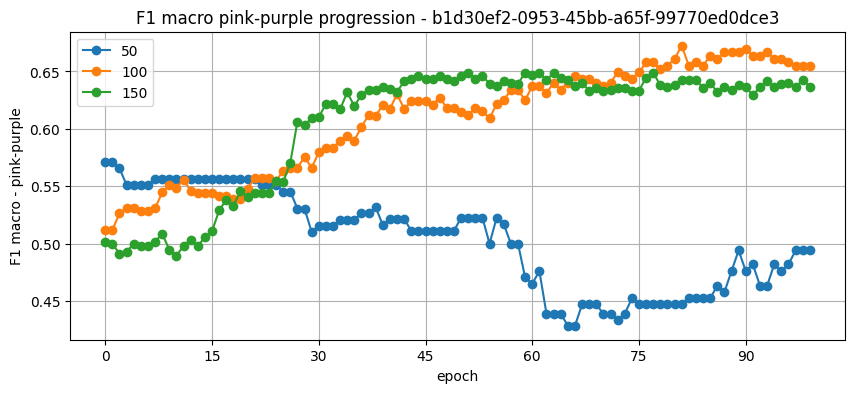

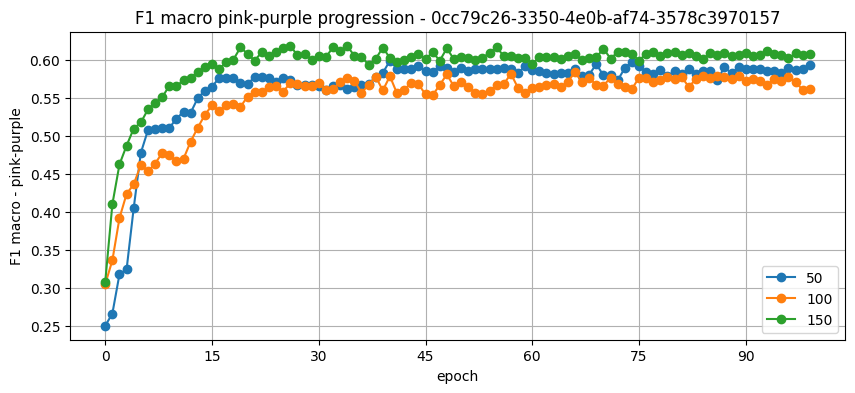

In [49]:
# PLOT finetune results for each class seperately
SAVE_FIG = True
# run_name = "swinv2tiny8020"
run_name = "convnexttiny8020-fixedmetrics"
output_dir = Path("finetuning/plots/per-class")
output_dir.mkdir(exist_ok=True)
class_to_plot = 'pink-purple'
class_dir = output_dir / class_to_plot
class_dir.mkdir(exist_ok=True)
print(class_dir, class_dir.exists())
for uuid, splits in METRICS_DICT.items():
# for uuid, splits in METRICS_D.items():
  # print(splits)
  plt.figure(figsize=(10, 4))
  for split in ["50", "100", "150"]:
    values = splits[split][class_to_plot]
    steps = list(range(len(values)))  # x-axis = progression steps

    plt.plot(steps, values, marker='o', label=f"{split}")

  plt.title(f"F1 macro {class_to_plot} progression - {uuid}")
  plt.xlabel("epoch")
  plt.ylabel(f"F1 macro - {class_to_plot}")
  plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True)) # to remove 0.25, 0.5 .. from x axis
  plt.legend()
  plt.grid(True)

  # save figure
  if SAVE_FIG:
    filename = class_dir / f"{run_name}-{uuid}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

  plt.show()
  plt.close()

In [ ]:
# NOTE: Print/save distribution of classes per dataset
# from collections import Counter

# output_dir = Path("finetuning/plots/distributions")
# output_dir.mkdir(exist_ok=True)

# LABEL_IDS = [0,1,2,3,4]
# CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
# CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS}

# N_IMAGES_TO_USE_IN_FINETUNE = [50, 100, 150]
# for n_images in N_IMAGES_TO_USE_IN_FINETUNE:
#   # ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted-{n_images}"
#   ROOT = Path().cwd().parents[0] / "data" / "processed" / f"finetuning-splitted8020-{n_images}" # for finetuning on 80-20 split
#   # for uuid_dir in islice(ROOT.iterdir(), 2):
#   for uuid_dir in ROOT.iterdir():
#     print(f"UUID = {uuid_dir.name} Sample {n_images}")
#     train_loader, dev_loader = get_loaders(uuid_dir)
#     train_counts = Counter(train_loader.dataset.targets)
#     dev_counts = Counter(dev_loader.dataset.targets)
    
#     train_values = [train_counts[i] for i in range(len(CLASS_NAMES))]
#     dev_values   = [dev_counts[i] for i in range(len(CLASS_NAMES))]
#     fig, ax = plt.subplots(figsize=(8, 4))
#     x = np.arange(len(CLASS_NAMES))
#     width = 0.4
#     train_bars = ax.bar(x - width/2, train_values, width, label="Train")
#     ax.bar_label(train_bars, labels=[str(v) for v in train_values], padding=3, fontsize=8)

#     dev_bars = ax.bar(x + width/2, train_values, width, label="Dev")
#     ax.bar_label(dev_bars, labels=[str(v) for v in dev_values], padding=3, fontsize=8)
#     ax.set_xticks(x)
#     ax.set_xticklabels(CLASS_NAMES, rotation=45)
#     ax.set_ylabel("Number of images")
#     ax.set_title(f"{uuid_dir.name} ({n_images} samples)")
#     ax.legend()

#     # save plots
#     filename = output_dir / f"{uuid_dir.name}-{n_images}.png"
#     plt.savefig(filename, dpi=300, bbox_inches="tight")

#     plt.tight_layout()
#     plt.show()

#     # print("Train:")
#     # for class_name, class_idx in train_loader.dataset.class_to_idx.items():
#     #   print(f"{class_name}: {train_counts[class_idx]}")

#     # print("\nDev:")
#     # for class_name, class_idx in dev_loader.dataset.class_to_idx.items():
#     #   print(f"{class_name}: {dev_counts[class_idx]}")

In [ ]:
# save metrics - Carefull not to override something!
import pickle
import json
# with open("convnexttiny-finetune.pkl", "wb") as f:
  # pickle.dump(dict(METRICS_DICT), f)

# metrics_save_path = "convnexttiny-finetune.json"
# metrics_save_path = "swinv2tiny-finetune8020.json"
# with open(metrics_save_path, "w") as f:
  # json.dump(dict(METRICS_DICT), f, indent=2)

In [ ]:
## Observations

- To 7db den exei katholou blue sto dev/ set gia 50 kai 100 samples kai exei 1 gia 150 sample! (den exei out buds auto)

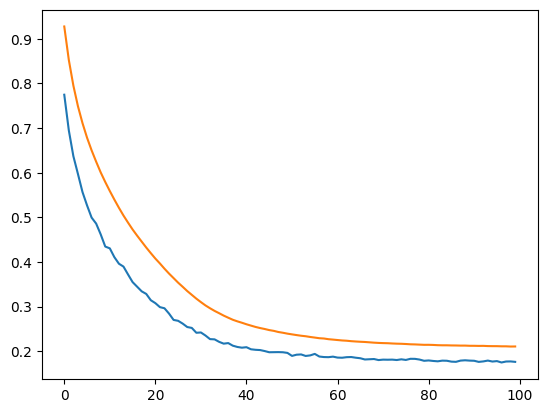

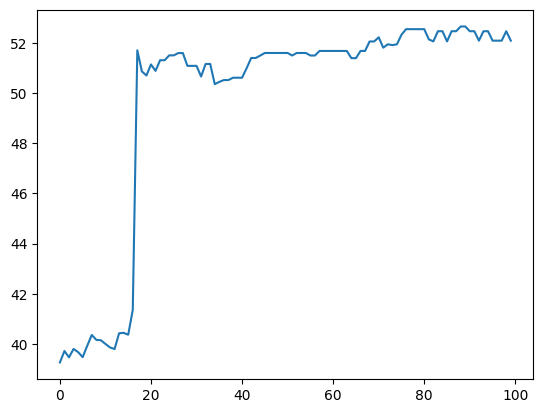

In [39]:
plt.plot(lossi)
plt.plot(dev_lossi)
plt.show()
plt.plot(dev_f1_macro);
plt.show()

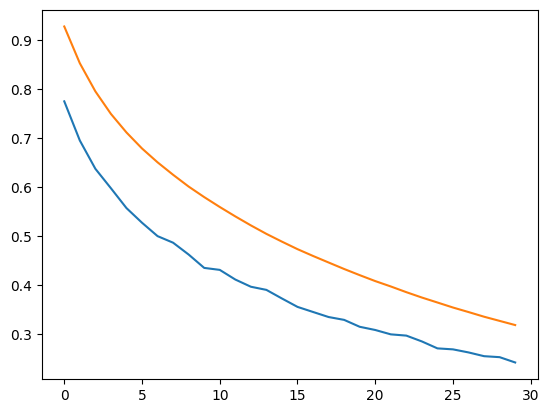

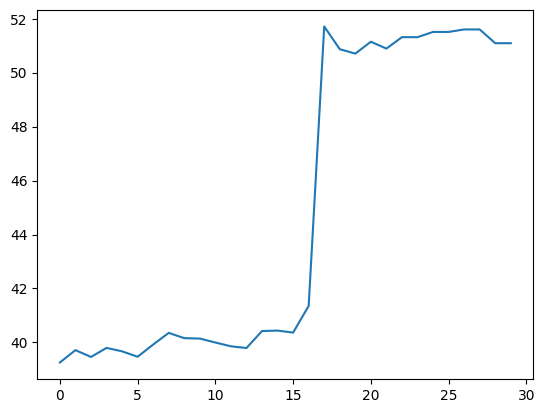

In [37]:
# 50 samples uuid: 33424749-501c-425e-bea5-3c74fb8539b4
plt.plot(lossi)
plt.plot(dev_lossi)
plt.show()
plt.plot(dev_f1_macro);
plt.show()

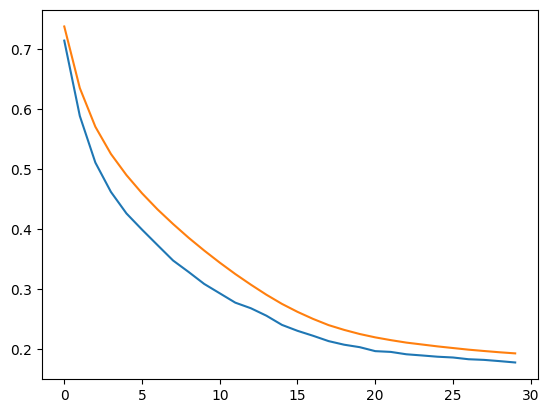

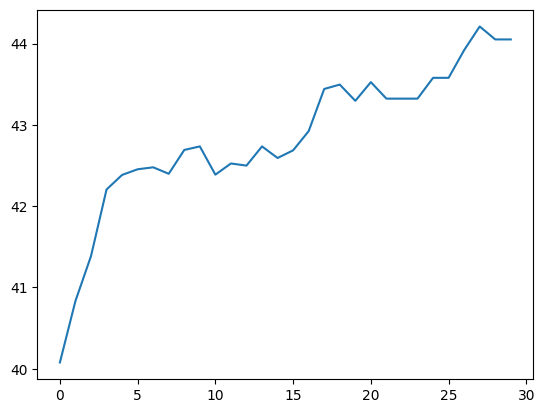

In [ ]:
# 100 samples uuid: 33424749-501c-425e-bea5-3c74fb8539b4
plt.plot(lossi)
plt.plot(dev_lossi)
plt.show()
plt.plot(dev_f1_macro);
plt.show()

In [12]:
BASE = Path().cwd().parents[0] / "data" / "processed"
base_dirs = [
  BASE / "finetuning-splitted-50",
  BASE / "finetuning-splitted-100",
  BASE / "finetuning-splitted-150",
]
LABEL_IDS = [0,1,2,3,4]
CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS}

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
for base in base_dirs:
  base_path = Path(base)
  print(f"\n=== {base.name} ===")

  for uuid_dir in sorted(base_path.iterdir()):
    if not uuid_dir.is_dir():
      continue

    print(f"\nUUID: {uuid_dir.name}")

    for split in ["train", "dev"]:
      split_path = uuid_dir / split
      if not split_path.exists():
        continue

      print(f"{split}:")

      for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
          continue

        count = sum(1 for f in class_dir.iterdir() if f.suffix.lower() in image_exts)
        # print(f"class {class_dir.name}: {count}")
        print(f"\t{CLASS_MAPPING[class_dir.name]}: {count}")


=== finetuning-splitted-50 ===

UUID: 0cc79c26-3350-4e0b-af74-3578c3970157
train:
	bud: 920
	flower: 194
	green: 2743
	pink-purple: 676
	blue: 2878
dev:
	bud: 103
	flower: 22
	green: 305
	pink-purple: 76
	blue: 320

UUID: 33424749-501c-425e-bea5-3c74fb8539b4
train:
	bud: 0
	flower: 29
	green: 11293
	pink-purple: 658
	blue: 473
dev:
	bud: 0
	flower: 4
	green: 1255
	pink-purple: 74
	blue: 53

UUID: 7dbfaa1b-19f1-479c-ab0a-b8081516de33
train:
	bud: 0
	flower: 2995
	green: 6068
	pink-purple: 19
	blue: 0
dev:
	bud: 0
	flower: 333
	green: 675
	pink-purple: 3
	blue: 0

UUID: b1d30ef2-0953-45bb-a65f-99770ed0dce3
train:
	bud: 8
	flower: 10
	green: 1009
	pink-purple: 242
	blue: 477
dev:
	bud: 1
	flower: 2
	green: 113
	pink-purple: 27
	blue: 53

UUID: d83c7c85-54d9-4b6e-ab2e-3fdec827c22c
train:
	bud: 0
	flower: 172
	green: 496
	pink-purple: 23
	blue: 85
dev:
	bud: 0
	flower: 20
	green: 56
	pink-purple: 3
	blue: 10

UUID: f54bc9dd-bb2e-4b46-b332-a14a594245a9
train:
	bud: 0
	flower: 32
	green: 982

In [ ]:
0cc79c26-3350-4e0b-af74-3578c3970157  (exei buds)
  - train and dev box images seem to scale OK with sample size

33424749-501c-425e-bea5-3c74fb8539b4  (no buds, apo 1 dev bud sta 100-150)
  - train and dev box images seem to scale OK with sample size

7dbfaa1b-19f1-479c-ab0a-b8081516de33 (no buds, elaxista pink-purple(finetune se 5-6 sta 100-150 samples), no blues (mono 1 dev sta 150))
  - train and dev box images scale for flower, green and pink-purple, But has very few pink-purple and no blue

b1d30ef2-0953-45bb-a65f-99770ed0dce3 (elaxista buds, poli liga flower, exei bolika blue kai pink-purple)
  - buds scale in dev/ like 1->2->3 (corresponding to 50->100->150 samples)
  - exei ligotera flower sto 100 sample (7 train and 1 dev) apo oti sto 50 sample (10 train 2 dev)!!
  - ta green/pink-purple kai blue scalaroun swsta

d83c7c85-54d9-4b6e-ab2e-3fdec827c22c (no buds, elaxista pink-purple)
  - green kai flower scalaroun swsta
  - pink scalaroun swsta, alla einai elaxista
  - kai ta blue scalaroun swsta, alla einai sxetika liga (276 train, 31 dev sto 150 sample)

d83c7c85-54d9-4b6e-ab2e-3fdec827c22c (exei 1-2 buds, polla green)
  - green kai flower scalaroun kala 
  - polla green, liga flower
  - ta pink kai blue scalaroun apo 50-100 alla sta 150 sample dn scalaroun toso (mallon den iparxoun arketa sto dataset ?)

#### Inference on the boxes one by one

In [ ]:
# # uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9", "33424749-501c-425e-bea5-3c74fb8539b4", "d83c7c85-54d9-4b6e-ab2e-3fdec827c22c",
#         #  "7dbfaa1b-19f1-479c-ab0a-b8081516de33", "0cc79c26-3350-4e0b-af74-3578c3970157", "b1d30ef2-0953-45bb-a65f-99770ed0dce3"]
# uuid = "f54bc9dd-bb2e-4b46-b332-a14a594245a9"
# # uuids = ["f54bc9dd-bb2e-4b46-b332-a14a594245a9"]
# # for uuid in tqdm(uuids, desc="datasets", position=0):
# TEST_DATASET_ROOT = Path().cwd().parents[0] / "data" / "processed" / "finetuning-global-labels" / uuid
# IMAGES_DIR = TEST_DATASET_ROOT / "images"
# LABELS_DIR = TEST_DATASET_ROOT / "labels"
# LABEL_IDS = [0, 1, 2, 3, 4]
# CLASS_NAMES = ["bud", "flower", "green", "pink-purple", "blue"]
# CLASS_MAPPING = {str(id):CLASS_NAMES[id] for id in LABEL_IDS} # for use in classification report df

# y_true = []
# y_pred = []
# # for i, label_file in islice(enumerate(LABELS_DIR.iterdir()), 5):
# for label_file in tqdm(LABELS_DIR.iterdir()):
#   if uuid == "f54bc9dd-bb2e-4b46-b332-a14a594245a9":
#     img_file = IMAGES_DIR / label_file.with_suffix('.jpg').name
#   else:
#     img_file = IMAGES_DIR / label_file.with_suffix('.png').name
#   img_rgb = Image.open(img_file).convert("RGB")
#   img_h, img_w = img_rgb.height, img_rgb.width
#   assert img_h == 2048 and img_w == 1536, "image dimensions different than expected"

#   gt_boxes = load_gt(label_file, img_h, img_w) # a list of (label, [x1,y1,x2,y2])
#   y_true_per_image = []
#   y_pred_per_image = []
#   for gt in gt_boxes:
#     gt_cls, gt_box = gt
#     crop = img_rgb.crop(gt_box)
#     crop_transformed = inference_transform(crop).unsqueeze(0).to(DEVICE)
#     with torch.inference_mode():
#       logits = classifier(crop_transformed).cpu()
#       classifier_probs = nn.Softmax(dim=1)(logits).cpu() # (1, n_classes)
#     classifier_pred = logits.argmax(dim=1).cpu().item()
#     classifier_conf = classifier_probs[:, classifier_pred].cpu().item()
#     y_true_per_image.append(gt_cls)
#     y_pred_per_image.append(classifier_pred)

#   y_true.extend(y_true_per_image)
#   y_pred.extend(y_pred_per_image)

# classifier_metrics = compute_classification_metrics_for_classifier_yolo_comparison(y_pred, y_true, LABEL_IDS)
# classifier_classification_report = classifier_metrics['classification_report']

# tqdm.write(f"UUID = {uuid}")
# tqdm.write(f"acc {classifier_metrics['acc']:.2f}% | " f"balanced_acc: {classifier_metrics['balanced_acc']:.2f}% | "
#       f"f1_macro: {classifier_metrics['f1_macro']:.2f}% | " f"f1_weighted: {classifier_metrics['f1_weighted']:.2f}% | "
#       f"precision_macro: {classifier_metrics['precision_macro']:.2f}% | " f"precision_weighted: {classifier_metrics['precision_weighted']:.2f}% | "
#       f"recall_macro: {classifier_metrics['recall_macro']:.2f}% | " f"recall_weighted: {classifier_metrics['recall_weighted']:.2f}%"
# )
# METRIC_COLUMNS = ["precision", "recall", "f1-score"]
# classifier_df = pd.DataFrame(classifier_classification_report).transpose()
# classifier_df = classifier_df.rename(index=CLASS_MAPPING)
# classifier_df[METRIC_COLUMNS] = classifier_df[METRIC_COLUMNS] * 100
# classifier_df["support"] = classifier_df["support"].astype(int)
# display(classifier_df.style.format(precision=3).set_caption("Classifier"))

# classifier_conf_matrix = classifier_metrics['confusion_matrix']
# fig, ax = plt.subplots(1, 1, figsize=(12,5))
# disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix, display_labels=CLASS_NAMES)
# # disp_conf_matrix = ConfusionMatrixDisplay(classifier_conf_matrix)
# disp_conf_matrix.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
# ax.set_title("Classifier");
# plt.show()